# Portfolio Optimization with PPO (standard model-free RL)

Same data pipeline as `FinRL_PortfolioOptimizationEnv_Demo.ipynb`, but the agent is
Stable-Baselines3 **PPO** instead of the built-in `PolicyGradient`.

| | `PolicyGradient` (demo) | **PPO (this notebook)** |
|---|---|---|
| gradient | analytic, differentiates the reward | sampled estimate |
| critic | none | learned value function |
| discount | none (implicit gamma=1) | gamma = 0.99 |
| exploration | none | gaussian noise |
| env reward used? | no (recomputed from `info`) | **yes** |

PPO needs the gymnasium API, so we use `PortfolioOptimizationGymnasiumEnv`, a thin
subclass that leaves the original environment untouched.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch as th
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MaxAbsScaler
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, CallbackList
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import GroupByScaler
from finrl.meta.env_portfolio_optimization.env_portfolio_optimization_gymnasium import (
    PortfolioOptimizationGymnasiumEnv,
)

SEED = 0
th.manual_seed(SEED)
np.random.seed(SEED)

device = "cpu"  # these policies run faster on CPU than GPU
print("device:", device)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


device: cpu


## 1. Data

In [2]:
TOP_STOCKS = [
    "NVDA", "AAPL", "MSFT", "GOOGL", "AMZN"
]
len(TOP_STOCKS)

5

In [3]:
portfolio_raw_df = YahooDownloader(
    start_date="2011-01-01",
    end_date="2022-12-31",
    ticker_list=TOP_STOCKS,
).fetch_data()

portfolio_raw_df.head()

YF deprecation warning: set proxy via new config function: yf.set_config(proxy=proxy)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (15100, 8)


Price,date,close,high,low,open,volume,tic,day
0,2011-01-03,9.865818,9.886474,9.724224,9.748172,445138400,AAPL,0
1,2011-01-03,9.211000,9.300000,9.060500,9.068500,106628000,AMZN,0
2,2011-01-03,14.990945,15.021704,14.795729,14.795729,94513392,GOOGL,0
3,2011-01-03,21.251337,21.403241,21.205766,21.304503,53443800,MSFT,0
4,2011-01-03,0.362166,0.365600,0.354840,0.355298,817448000,NVDA,0


### Freeze the download

Yahoo recomputes adjusted prices every time a dividend is paid, so the *same* request
returns different numbers months later. Save the frame once and read from disk
afterwards, otherwise experiments are not reproducible.

In [4]:
portfolio_raw_df.to_csv("portfolio_raw_frozen.csv", index=False)

# on later runs, load instead of re-downloading:
# portfolio_raw_df = pd.read_csv("portfolio_raw_frozen.csv")

### Sanity check

`YahooDownloader` back-adjusts open/high/low/close by the same daily factor, so bars
should stay self-consistent. Two very different things can break that:

- **A handful of bad bars** (~0.05% of rows) - Yahoo's source data genuinely contains
  bad ticks. Clip them and move on.
- **Most rows violating** - the adjustment only touched `close`, leaving high/low on a
  different price basis. That data is unusable; the three feature channels would
  contradict each other.

In [5]:
viol = (portfolio_raw_df["close"] > portfolio_raw_df["high"]) | (
    portfolio_raw_df["close"] < portfolio_raw_df["low"]
)
print(f"inconsistent bars: {viol.sum()} / {len(portfolio_raw_df)} ({viol.mean():.3%})")

assert viol.mean() < 0.01, (
    "OHLC is systematically inconsistent - the price adjustment likely only touched "
    "`close`. Do not train on this data."
)

# clip the isolated bad ticks so low <= close <= high holds everywhere
portfolio_raw_df["high"] = portfolio_raw_df[["high", "close"]].max(axis=1)
portfolio_raw_df["low"] = portfolio_raw_df[["low", "close"]].min(axis=1)

counts = portfolio_raw_df.groupby("tic")["date"].count()
print(f"days per tic: {counts.unique()}")
assert counts.nunique() == 1, "tics must share the same date set"

inconsistent bars: 0 / 15100 (0.000%)
days per tic: [3020]


### Normalize and split

Three-way split. **2019 is held out as a validation period** so training can be
monitored for overfitting without ever touching 2020-2022.

`MaxAbsScaler` divides each ticker by its own maximum. Fitting it on the whole frame
*before* splitting leaks the future: 7 of these 10 tickers peak after 2019, so a training
observation of `close = 0.6` would quietly encode "40% below a high that has not happened
yet". Fit on the training years only; values above 1.0 elsewhere are expected and correct.

The scaling cancels out of the return calculation (`close_t / close_{t-1}`), so this
changes only what the network sees, not how performance is measured.

In [6]:
def slice_raw(df, start, end):
    return df[(df["date"] >= start) & (df["date"] < end)]

raw_train = slice_raw(portfolio_raw_df, "2011-01-01", "2019-01-01")
raw_valid = slice_raw(portfolio_raw_df, "2019-01-01", "2020-01-01")
raw_2020 = slice_raw(portfolio_raw_df, "2020-01-01", "2021-01-01")
raw_2021 = slice_raw(portfolio_raw_df, "2021-01-01", "2022-01-01")
raw_2022 = slice_raw(portfolio_raw_df, "2022-01-01", "2023-01-01")

COLS = ["date", "tic", "close", "high", "low"]
scaler = GroupByScaler(by="tic", scaler=MaxAbsScaler, columns=["close", "high", "low"])

df_train = scaler.fit_transform(raw_train)[COLS]      # fit happens here only
df_valid = scaler.transform(raw_valid)[COLS]
df_2020 = scaler.transform(raw_2020)[COLS]
df_2021 = scaler.transform(raw_2021)[COLS]
df_2022 = scaler.transform(raw_2022)[COLS]

for name, d in [("train", df_train), ("valid", df_valid), ("2020", df_2020),
                ("2021", df_2021), ("2022", df_2022)]:
    print(f"{name:6s} {d['date'].min()} .. {d['date'].max()}  ({d['date'].nunique():4d} days)"
          f"   close range [{d['close'].min():.3f}, {d['close'].max():.3f}]")

train  2011-01-03 .. 2018-12-31  (2012 days)   close range [0.036, 1.000]
valid  2019-01-02 .. 2019-12-31  ( 252 days)   close range [0.443, 1.401]
2020   2020-01-02 .. 2020-12-31  ( 253 days)   close range [0.682, 2.420]
2021   2021-01-04 .. 2021-12-31  ( 252 days)   close range [1.340, 4.648]
2022   2022-01-03 .. 2022-12-30  ( 251 days)   close range [0.802, 4.195]


## 2. Network architecture

`MultiInputPolicy`'s default extractor flattens everything: the `(3, 10, 50)` price
tensor becomes a 1500-dim vector, so the first layer alone carries `1511 x 64 ~ 97k`
parameters - against only ~2000 unique trading days. Worse, flattening throws away two
structures that are free if you keep them:

- **time locality** - dimension 0 and 1 are adjacent days; 0 and 500 are not
- **asset exchangeability** - the same rule should evaluate all 10 tickers

`EIIEExtractor` is the convolution stack from the EIIE paper. Its kernel is `(1, k_size)`:
it convolves **along time** and **shares weights across assets** - that is what "ensemble
of identical independent evaluators" means. It reduces the feature vector to
`20 x 10 + 11 = 211` with ~2000 parameters, a ~50x cut with a better prior.

Switch between the two with `ARCH` below to see how much it actually matters.

In [7]:
class EIIEExtractor(BaseFeaturesExtractor):
    """EIIE convolution stack as an SB3 features extractor.

    Convolves along the time axis with weights shared across assets, then concatenates
    the agent's current holdings.
    """

    def __init__(self, observation_space, k_size=3, conv_mid=2, conv_final=20):
        n_features, n_assets, time_window = observation_space["state"].shape
        n_last = observation_space["last_action"].shape[0]
        super().__init__(observation_space, features_dim=conv_final * n_assets + n_last)

        n_size = time_window - k_size + 1
        self.conv = nn.Sequential(
            nn.Conv2d(n_features, conv_mid, kernel_size=(1, k_size)),
            nn.ReLU(),
            nn.Conv2d(conv_mid, conv_final, kernel_size=(1, n_size)),
            nn.ReLU(),
            nn.Flatten(),
        )

    def forward(self, obs):
        return th.cat([self.conv(obs["state"]), obs["last_action"]], dim=1)

## 3. Environment and run config

Four settings differ from the demo. The first two are required by PPO; the last two fix
defects found by diagnosing the first runs.

- **`reward_scaling=100`** - PPO consumes the env reward directly (`PolicyGradient`
  ignores it and recomputes from `info`). Log returns sit around +-0.02, too small for
  the advantages to survive critic noise.
- **`action_space_mode="symmetric"`** - SB3 clips actions to the declared space. Under
  the original `Box(0, 1)` the softmax input range is only `[0, 1]`, capping any single
  weight at `e / (e + 10) = 0.21`; the agent could never concentrate or go to cash.
- **`return_last_action=True`** - without it the observation is only the price tensor, so
  the agent is charged commission on turnover **while unable to see what it currently
  holds**. EIIE gets this through its Portfolio Vector Memory; the PPO setup was missing
  it. This makes the observation a `Dict`, hence `MultiInputPolicy`.
- **`log_std_init=-2.0`** - `action_scale` multiplies the mean *and* the noise. At the SB3
  default (`std = 1`) the logit-space noise is `1 x 5 = 5`, as large as the entire useful
  range, so training rollouts were near-random while evaluation used the noise-free mean.
  The two differed by ~580x. `exp(-2) = 0.135` brings that noise down to `0.68`.

Note: `last_action` is the weight vector the agent *chose* last step, before prices
drifted it. The env charges fees against the drifted weights, so this is a close
approximation - the same one the repo's own PVM makes.

### The config ladder

| config | commission | question it answers |
|---|---|---|
| `A_no_fee` | 0 | Can the agent learn allocation *at all*? Does it beat buy-and-hold? |
| `B_with_fee` | 0.25% | Does the edge survive realistic costs? |

In [8]:
POLICY = "MultiInputPolicy"   # observation is a Dict once return_last_action=True

BASE_ENV_KWARGS = dict(
    initial_amount=100000,
    time_window=50,
    features=["close", "high", "low"],
    normalize_df=None,          # already scaled above
    reward_scaling=100,
    action_space_mode="symmetric",
    return_last_action=True,    # the agent must see what it currently holds
    plot_on_terminal=False,     # skip per-episode matplotlib/quantstats dumps
)

BASE_PPO_KWARGS = dict(
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.0,
    device=device,
    seed=SEED,
    verbose=1,
)

BASE_POLICY_KWARGS = dict(log_std_init=-2.0)   # std = 0.135, not the SB3 default 1.0

ARCHITECTURES = {
    "flat": dict(),                                     # SB3 default: flatten everything
    "eiie": dict(features_extractor_class=EIIEExtractor,
                 features_extractor_kwargs=dict(k_size=3, conv_mid=2, conv_final=20)),
}

CONFIGS = {
    "A_no_fee":   {"comission_fee_pct": 0.0},
    "B_with_fee": {"comission_fee_pct": 0.0025},
}

# ---- switch here, then rerun from this cell down --------------------------------
CONFIG = "A_no_fee"
ARCH = "eiie"
# --------------------------------------------------------------------------------

RUN = f"{CONFIG}_{ARCH}"
ENV_KWARGS = {**BASE_ENV_KWARGS, **CONFIGS[CONFIG]}
PPO_KWARGS = {**BASE_PPO_KWARGS,
              "policy_kwargs": {**BASE_POLICY_KWARGS, **ARCHITECTURES[ARCH]}}

std = np.exp(BASE_POLICY_KWARGS["log_std_init"])
print(f"run         : {RUN}")
print(f"  commission: {ENV_KWARGS['comission_fee_pct']}")
print(f"  ent_coef  : {PPO_KWARGS['ent_coef']}")
print(f"  std       : {std:.3f}  ->  logit-space noise = {std * 5:.2f}")
print(f"  extractor : {ARCH}")

run         : A_no_fee_eiie
  commission: 0.0
  ent_coef  : 0.0
  std       : 0.135  ->  logit-space noise = 0.68
  extractor : eiie


In [9]:
environment = PortfolioOptimizationGymnasiumEnv(df_train, **ENV_KWARGS)

obs, _ = environment.reset(seed=SEED)
print("observation:")
for k, v in obs.items():
    print(f"  {k:12s} {v.shape}")
print("action space:", environment.action_space)
print("max weight a single asset can reach:", round(environment.max_achievable_weight(), 4))

observation:
  state        (3, 5, 50)
  last_action  (6,)
action space: Box(-1.0, 1.0, (6,), float32)
max weight a single asset can reach: 0.9998


### How the reward is designed

```
reward_t = reward_scaling * log( mu_t * sum_i(w_i * y_i) )
                                  |          |     |
                                  |          |     +-- price variation (cash entry = 1)
                                  |          +-------- portfolio weights
                                  +------------------- commission factor (trf model)
```

Three things follow from using the **log** return rather than the simple return:

1. **It is additive.** `sum_t reward_t = reward_scaling * log(V_final / V_initial)`, so
   maximizing cumulative reward is exactly maximizing final wealth.
2. **It is scale-free.** A 1% gain scores the same on 100k as on 10M.
3. **It penalizes drawdowns on its own.** `log` is concave: `log(0.5) = -0.69` and
   `log(2.0) = +0.69` cancel, matching the fact that a 50% loss needs a 100% gain to
   recover. This is log-utility. There is **no explicit risk term** in the environment -
   all of the risk aversion comes from the concavity of the log.

## 4. Rollout helpers

`rollout` plays one full episode and returns performance plus two portfolio-specific
diagnostics. `model=None` plays the equal-weight buy-and-hold baseline.

Rewards are reported **per day** so periods of different length stay comparable - the
training block is ~2000 days and validation is ~250.

In [10]:
def rollout(env, model=None, seed=SEED):
    obs, _ = env.reset(seed=seed)
    n = env.action_space.shape[0]
    done = False
    while not done:
        if model is None:
            action = np.concatenate([[-1.0], np.zeros(n - 1)]).astype(np.float32)
        else:
            action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

    values = np.asarray(env._asset_memory["final"], dtype=float)
    chosen = np.asarray(env._actions_memory)     # weights the agent asked for
    drifted = np.asarray(env._final_weights)     # weights after prices moved
    steps = max(len(values) - 1, 1)
    reward = env._reward_scaling * np.log(values[-1] / values[0])

    return {
        "values": values,
        "reward": reward,
        "reward_per_day": reward / steps,
        "final_value": values[-1],
        # L1 distance between what the agent wanted and where prices left it: the
        # quantity commission is charged on
        "turnover": float(np.abs(chosen[1:] - drifted[:-1]).sum(axis=1).mean()),
        "max_weight": float(chosen[1:].max()),
    }


def run_policy(env, model=None):
    return rollout(env, model)["values"]


def metrics(values):
    daily = np.diff(values) / values[:-1]
    peak = np.maximum.accumulate(values)
    return {
        "final": values[-1],
        "return": values[-1] / values[0] - 1,
        "sharpe": daily.mean() / daily.std() * np.sqrt(252) if daily.std() > 0 else np.nan,
        "maxDD": ((values - peak) / peak).min(),
    }

## 5. Training monitors

Two callbacks:

- **`PortfolioTrainingLogger`** - per-episode reward of the *sampled* policy, plus PPO's
  own diagnostics. Cheap, records every episode.
- **`ValidationCallback`** - periodically runs the *deterministic* policy over both the
  training block and the held-out 2019 validation block. This is the only thing here that
  can detect overfitting, and it also saves the best checkpoint by validation reward
  rather than whatever the last episode happened to produce.

In [11]:
class PortfolioTrainingLogger(BaseCallback):
    """Per-episode reward of the sampled policy, plus PPO's own diagnostics."""

    def __init__(self, initial_amount, reward_scaling):
        super().__init__()
        self.initial_amount = initial_amount
        self.reward_scaling = reward_scaling
        self.episodes = []

    def _on_step(self):
        for info in self.locals["infos"]:
            ep = info.get("episode")          # populated by the Monitor wrapper
            if ep is not None:
                self.episodes.append({
                    "timesteps": self.num_timesteps,
                    "ep_reward": ep["r"],
                    "final_value": self.initial_amount * np.exp(ep["r"] / self.reward_scaling),
                })
        return True

    def _on_rollout_end(self):
        v = self.model.logger.name_to_value
        if self.episodes:
            self.episodes[-1].update({
                k: v.get(f"train/{k}")
                for k in ["explained_variance", "entropy_loss", "value_loss"]
            })

In [12]:
class ValidationCallback(BaseCallback):
    """Deterministic evaluation on train and held-out validation blocks.

    Records the generalization gap and saves the best checkpoint by validation reward.
    """

    def __init__(self, train_df, valid_df, env_kwargs, eval_freq=20_000, save_path="ppo_best"):
        super().__init__()
        self.train_df = train_df
        self.valid_df = valid_df
        self.env_kwargs = env_kwargs
        self.eval_freq = eval_freq
        self.save_path = save_path
        self.records = []
        self.best = -np.inf

    def _make(self, df):
        return PortfolioOptimizationGymnasiumEnv(df, **self.env_kwargs)

    def _on_training_start(self):
        # passive baselines, computed once
        self.bh_train = rollout(self._make(self.train_df))["reward_per_day"]
        self.bh_valid = rollout(self._make(self.valid_df))["reward_per_day"]
        print(f"buy & hold reward/day   train {self.bh_train:+.4f}   valid {self.bh_valid:+.4f}")
        self._evaluate()

    def _on_step(self):
        if self.n_calls % self.eval_freq == 0:
            self._evaluate()
        return True

    def _evaluate(self):
        tr = rollout(self._make(self.train_df), self.model)
        va = rollout(self._make(self.valid_df), self.model)
        rec = {
            "timesteps": self.num_timesteps,
            "train_reward": tr["reward_per_day"],
            "valid_reward": va["reward_per_day"],
            "gap": tr["reward_per_day"] - va["reward_per_day"],
            "train_excess": tr["reward_per_day"] - self.bh_train,
            "valid_excess": va["reward_per_day"] - self.bh_valid,
            "valid_final": va["final_value"],
            "turnover": va["turnover"],
            "max_weight": va["max_weight"],
        }
        rec["is_best"] = rec["valid_reward"] > self.best
        if rec["is_best"]:
            self.best = rec["valid_reward"]
            self.model.save(self.save_path)
        self.records.append(rec)

## 6. Train

In [13]:
train_env = Monitor(environment)      # Monitor is what fills info["episode"]

logger_cb = PortfolioTrainingLogger(ENV_KWARGS["initial_amount"], ENV_KWARGS["reward_scaling"])
valid_cb = ValidationCallback(df_train, df_valid, ENV_KWARGS,
                              eval_freq=20_000, save_path=f"ppo_best_{RUN}")

model = PPO(POLICY, train_env, **PPO_KWARGS)
print(model.policy)

Using cpu device
Wrapping the env in a DummyVecEnv.
MultiInputActorCriticPolicy(
  (features_extractor): EIIEExtractor(
    (conv): Sequential(
      (0): Conv2d(3, 2, kernel_size=(1, 3), stride=(1, 1))
      (1): ReLU()
      (2): Conv2d(2, 20, kernel_size=(1, 48), stride=(1, 1))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
    )
  )
  (pi_features_extractor): EIIEExtractor(
    (conv): Sequential(
      (0): Conv2d(3, 2, kernel_size=(1, 3), stride=(1, 1))
      (1): ReLU()
      (2): Conv2d(2, 20, kernel_size=(1, 48), stride=(1, 1))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
    )
  )
  (vf_features_extractor): EIIEExtractor(
    (conv): Sequential(
      (0): Conv2d(3, 2, kernel_size=(1, 3), stride=(1, 1))
      (1): ReLU()
      (2): Conv2d(2, 20, kernel_size=(1, 48), stride=(1, 1))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
    )
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=1

In [14]:
TOTAL_TIMESTEPS = 300_000   # ~35 min on CPU; 20_000 is enough for a smoke test

model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=CallbackList([logger_cb, valid_cb]))
model.save(f"ppo_last_{RUN}")

train_log = pd.DataFrame(logger_cb.episodes)
valid_log = pd.DataFrame(valid_cb.records)
valid_log.tail()

buy & hold reward/day   train +0.0943   valid +0.1404
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.96e+03 |
|    ep_rew_mean     | 162      |
| time/              |          |
|    fps             | 143      |
|    iterations      | 1        |
|    time_elapsed    | 14       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.96e+03    |
|    ep_rew_mean          | 173         |
| time/                   |             |
|    fps                  | 202         |
|    iterations           | 2           |
|    time_elapsed         | 20          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008082105 |
|    clip_fraction        | 0.0626      |
|    clip_range           | 0.2         |
|    entropy_loss         | 3.49        |
|    explained_var

,timesteps,train_reward,valid_reward,gap,train_excess,valid_excess,valid_final,turnover,max_weight,is_best
11,220000,0.112932,0.104119,0.008813,0.018592,-0.036315,123407.406250,0.016660,0.296193,False
12,240000,0.116742,0.101608,0.015134,0.022402,-0.038826,122782.984375,0.017440,0.325386,False
13,260000,0.118033,0.098623,0.019409,0.023693,-0.041811,122044.960938,0.016089,0.288106,False
14,280000,0.120971,0.101550,0.019420,0.026631,-0.038884,122768.703125,0.015353,0.305705,False
15,300000,0.124810,0.089913,0.034897,0.030470,-0.050522,119916.304688,0.015056,0.371005,False


## 7. Learning curves

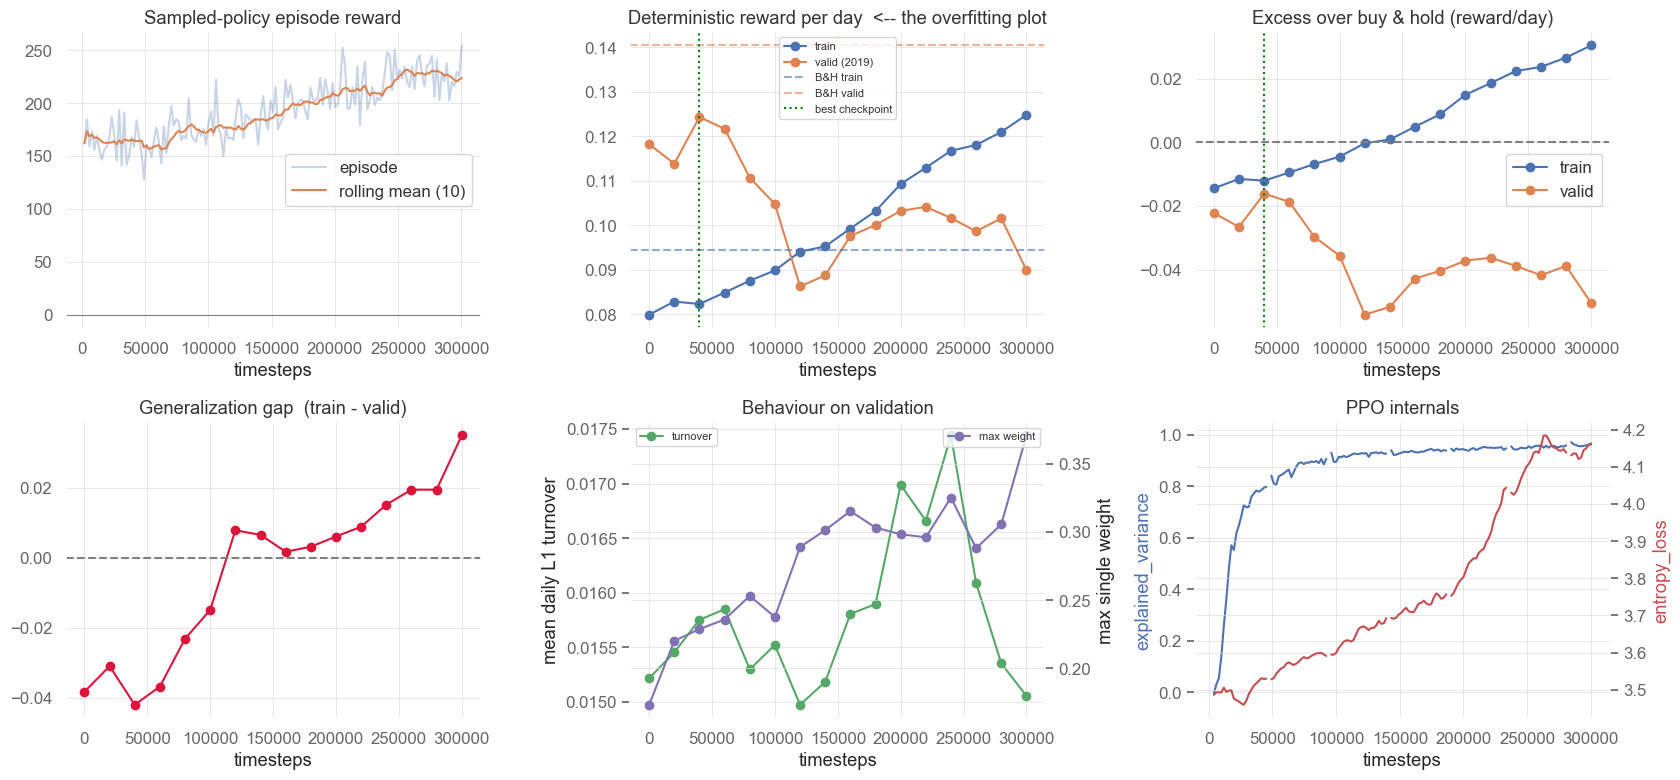

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
best_t = valid_log.loc[valid_log["valid_reward"].idxmax(), "timesteps"]

ax = axes[0, 0]
ax.plot(train_log["timesteps"], train_log["ep_reward"], alpha=0.3, label="episode")
ax.plot(train_log["timesteps"], train_log["ep_reward"].rolling(10, min_periods=1).mean(),
        label="rolling mean (10)")
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("Sampled-policy episode reward"); ax.set_xlabel("timesteps"); ax.legend()

ax = axes[0, 1]
ax.plot(valid_log["timesteps"], valid_log["train_reward"], "o-", label="train")
ax.plot(valid_log["timesteps"], valid_log["valid_reward"], "o-", label="valid (2019)")
ax.axhline(valid_cb.bh_train, color="C0", ls="--", alpha=.6, label="B&H train")
ax.axhline(valid_cb.bh_valid, color="C1", ls="--", alpha=.6, label="B&H valid")
ax.axvline(best_t, color="green", ls=":", label="best checkpoint")
ax.set_title("Deterministic reward per day  <-- the overfitting plot")
ax.set_xlabel("timesteps"); ax.legend(fontsize=8)

ax = axes[0, 2]
ax.plot(valid_log["timesteps"], valid_log["train_excess"], "o-", label="train")
ax.plot(valid_log["timesteps"], valid_log["valid_excess"], "o-", label="valid")
ax.axhline(0, color="grey", ls="--")
ax.axvline(best_t, color="green", ls=":")
ax.set_title("Excess over buy & hold (reward/day)"); ax.set_xlabel("timesteps"); ax.legend()

ax = axes[1, 0]
ax.plot(valid_log["timesteps"], valid_log["gap"], "o-", color="crimson")
ax.axhline(0, color="grey", ls="--")
ax.set_title("Generalization gap  (train - valid)"); ax.set_xlabel("timesteps")

ax = axes[1, 1]
ax.plot(valid_log["timesteps"], valid_log["turnover"], "o-", color="C2", label="turnover")
ax.set_ylabel("mean daily L1 turnover"); ax.set_xlabel("timesteps")
ax2 = ax.twinx()
ax2.plot(valid_log["timesteps"], valid_log["max_weight"], "o-", color="C4", label="max weight")
ax2.set_ylabel("max single weight")
ax.set_title("Behaviour on validation")
ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8)

ax = axes[1, 2]
ax.plot(train_log["timesteps"], train_log["explained_variance"], color="C0")
ax.set_ylabel("explained_variance", color="C0"); ax.set_ylim(-0.1, 1.05)
ax.set_xlabel("timesteps")
ax2 = ax.twinx()
ax2.plot(train_log["timesteps"], train_log["entropy_loss"], color="C3")
ax2.set_ylabel("entropy_loss", color="C3")
ax.set_title("PPO internals")

plt.tight_layout()
plt.show()

### How to read these

**Panel (0,1) is the one that answers "am I overfitting".** Overfitting looks like the
train curve continuing to rise while the validation curve flattens and then turns down.
The green dotted line marks the best validation checkpoint - anything to the right of it
is the model getting better at 2011-2018 specifically, not at investing.

```
reward │  train ────────/‾‾‾‾‾    keeps rising
 /day  │               /
       │  valid ──/‾╲___          peaks, then falls
       │         /   ^
       │────────/    +-- overfitting starts here
       +-------------------> timesteps
```

**Panel (0,2) is the one that answers "is this worth doing".** Both curves are relative
to buy-and-hold on their own period. If `valid_excess` never gets above 0, the agent is
not beating a passive portfolio out of sample no matter how good the training curve looks.

**Panel (1,1) catches a specific failure.** Turnover climbing while validation reward
stays flat means the agent is trading on noise it has memorized. Max weight pinned near
1.0 means it has collapsed onto a single asset.

**`explained_variance`** is `1 - Var(returns - critic) / Var(returns)`: near 0 the critic
is guessing and the advantages driving the policy are noise; 0.5-0.9 is healthy. Values
above 0.95 on financial data usually mean something is leaking.

**`entropy_loss`** is `-entropy`, so it should climb toward 0 as the policy commits.
Starting from `log_std_init=-2` it begins near `11 * (1.42 - 2) = -6.4`.

**Do not read the sampled-policy curve (0,0) as performance.** Actions are sampled during
training but taken at their mean during evaluation, so turnover differs.

## 8. Backtest

Uses the **best validation checkpoint**, not the final one. Each period restarts from the
initial capital, so the yearly numbers are independent.

In [16]:
best_model = PPO.load(f"ppo_best_{RUN}", device=device)
print(f"loaded best checkpoint from timestep {best_t}")

periods = {"train": df_train, "valid": df_valid,
           "2020": df_2020, "2021": df_2021, "2022": df_2022}

PPO_results, UBAH_results = {}, {}
for name, d in periods.items():
    PPO_results[name] = run_policy(PortfolioOptimizationGymnasiumEnv(d, **ENV_KWARGS), best_model)
    UBAH_results[name] = run_policy(PortfolioOptimizationGymnasiumEnv(d, **ENV_KWARGS))
    print(f"{name} done")

loaded best checkpoint from timestep 40000
train done
valid done
2020 done
2021 done
2022 done


In [17]:
rows = []
for name in periods:
    for label, res in [("PPO", PPO_results), ("Buy & Hold", UBAH_results)]:
        rows.append({"period": name, "agent": label, **metrics(res[name])})

summary = pd.DataFrame(rows)
for col, fmt in [("return", "{:.2%}"), ("maxDD", "{:.2%}"),
                 ("final", "{:,.0f}"), ("sharpe", "{:.2f}")]:
    summary[col] = summary[col].map(fmt.format)
summary

,period,agent,final,return,sharpe,maxDD
0,train,PPO,"502,407",402.41%,1.25,-28.09%
1,train,Buy & Hold,"636,589",536.59%,1.23,-33.10%
2,valid,PPO,"128,546",28.55%,1.89,-14.21%
3,valid,Buy & Hold,"132,800",32.80%,1.90,-16.26%
4,2020,PPO,"163,188",63.19%,2.03,-14.20%
5,2020,Buy & Hold,"175,870",75.87%,2.06,-15.98%
6,2021,PPO,"136,407",36.41%,2.36,-7.70%
7,2021,Buy & Hold,"148,069",48.07%,2.44,-9.23%
8,2022,PPO,"76,004",-24.00%,-0.83,-33.91%
9,2022,Buy & Hold,"71,973",-28.03%,-0.82,-39.21%


In [18]:
# compounded across the three untouched test years
oos = ["2020", "2021", "2022"]
for label, res in [("PPO", PPO_results), ("Buy & Hold", UBAH_results)]:
    chain = np.prod([res[y][-1] / res[y][0] for y in oos])
    print(f"{label:12s} out-of-sample 2020-2022: {chain - 1:+.2%}")

PPO          out-of-sample 2020-2022: +69.19%
Buy & Hold   out-of-sample 2020-2022: +87.43%


## 9. Plots

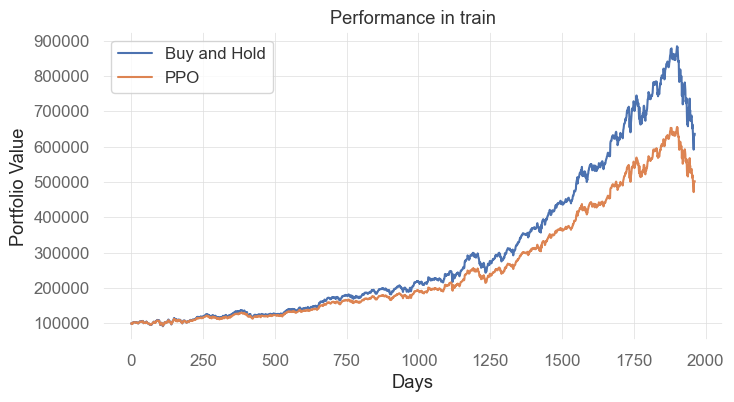

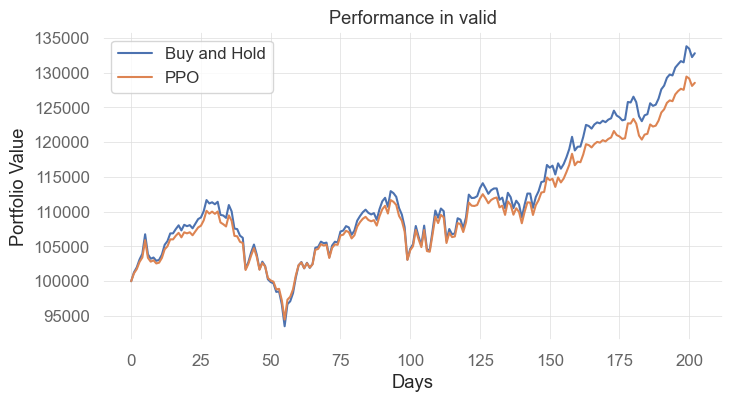

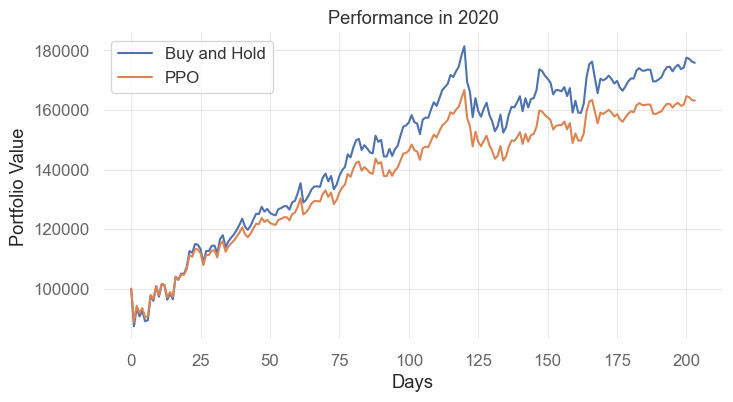

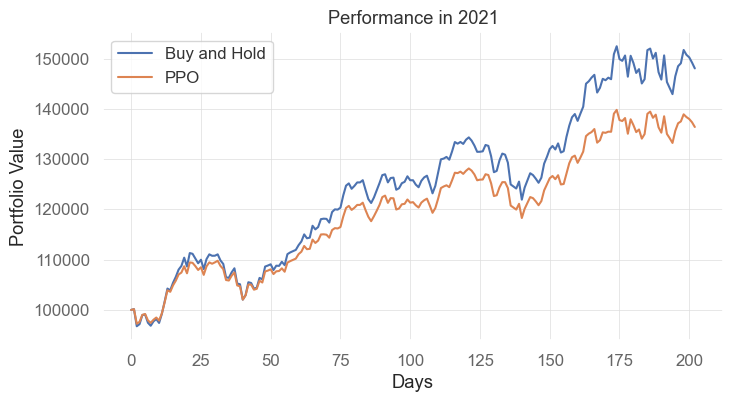

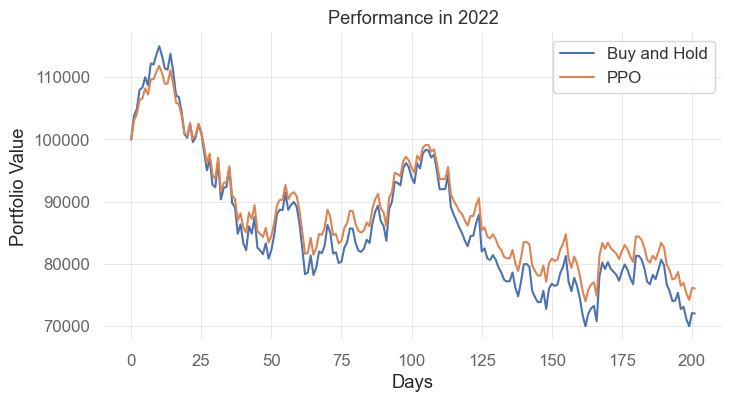

In [19]:
%matplotlib inline

for name in periods:
    plt.figure(figsize=(8, 4))
    plt.plot(UBAH_results[name], label="Buy and Hold")
    plt.plot(PPO_results[name], label="PPO")
    plt.xlabel("Days"); plt.ylabel("Portfolio Value")
    plt.title(f"Performance in {name}")
    plt.legend(); plt.show()

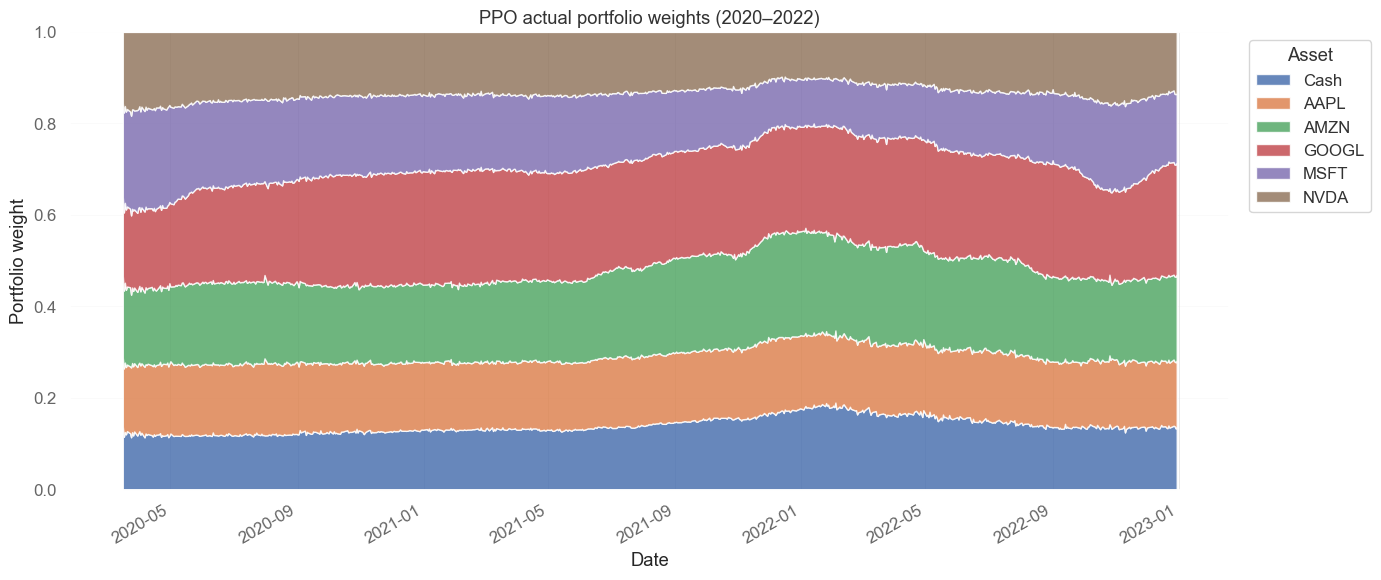

In [20]:
# Actual end-of-day portfolio weights on the continuous test period
WEIGHT_PERIODS = ("2020", "2021", "2022")
weight_df = (
    pd.concat([periods[name] for name in WEIGHT_PERIODS], ignore_index=True)
    .sort_values(["date", "tic"], ignore_index=True)
)
weight_env = PortfolioOptimizationGymnasiumEnv(weight_df, **ENV_KWARGS)
weight_obs, _ = weight_env.reset(seed=SEED)
weight_done = False
while not weight_done:
    weight_action, _ = best_model.predict(weight_obs, deterministic=True)
    weight_obs, _, weight_terminated, weight_truncated, _ = weight_env.step(weight_action)
    weight_done = weight_terminated or weight_truncated

# _final_weights contains the actual weights after each day's price movement.
weight_dates = pd.to_datetime(weight_env._date_memory[1:])
weight_values = np.asarray(weight_env._final_weights[1:], dtype=float)
weight_labels = ["Cash", *weight_env._tic_list.tolist()]

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(weight_dates, weight_values.T, labels=weight_labels, alpha=0.85)
ax.set_title(f"PPO actual portfolio weights ({WEIGHT_PERIODS[0]}–{WEIGHT_PERIODS[-1]})")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio weight")
ax.set_ylim(0, 1)
ax.legend(title="Asset", loc="upper left", bbox_to_anchor=(1.01, 1))
ax.grid(axis="y", alpha=0.2)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Caveats

**One seed proves nothing.** PPO is sensitive to initialization, and consecutive episodes
on the *same* data have varied by 5x in earlier runs. Rerun with several `SEED` values
and report the spread.

**There is enough capacity to memorize.** ~2000 unique trading days replayed ~150 times at
300k timesteps; each 50-day window is effectively a unique key. `ARCH="eiie"` cuts the
first-layer parameters ~50x and adds the right prior, but does not eliminate the risk -
that is what the validation curve is for.

**Only one price path exists.** No augmentation, no parallel environments; the agent sees
the single realization history happened to take. This is the motivation for training on
generated data.

**Validation is one year.** 2019 is ~250 days of a single market regime. A checkpoint that
looks best on it may simply suit that regime.